In [1]:
import numpy as np
from numpy import sin, pi, exp
import matplotlib.pyplot as plt

# generate support data files for tutorial Southern Ocean Reentrant Channel
# hard-coded for eddying resolution: dx=dy=5 km (Cartesian)
# to exactly match the bathymetry and forcing in the coarse-res setup

# grid depths generated Using the hyperbolic tangent method of 
# Stewart et al. (2017) DOI: 10.1016/j.ocemod.2017.03.012
# to design an optimal grid.
# https://github.com/kialstewart/vertical_grid_for_ocean_models

dr = np.array([5.48716549,   6.19462098,   6.99291201,   7.89353689, \
               8.90937723,  10.05483267,  11.34595414,  12.80056778, \
              14.43837763,  16.28102917,  18.35210877,  20.67704362, \
              23.28285446,  26.1976981 ,  29.45012046,  33.06792588, \
              37.07656002,  41.496912  ,  46.34247864,  51.61592052, \
              57.30518684,  63.37960847,  69.78661289,  76.44996107, \
              83.27047568,  90.13003112,  96.89898027, 103.44631852, \
             109.65099217, 115.4122275 , 120.65692923, 125.34295968, \
             129.45821977, 133.01641219, 136.05088105, 138.60793752, \
             140.74074276, 142.50436556, 143.95220912, 145.133724  , \
             146.09317287, 146.86917206, 147.49475454, 147.99774783, \
             148.40131516, 148.72455653, 148.98310489, 149.18968055, \
             149.35458582])
nx = 600
ny = 1200
nr = len(dr)
rF = (np.insert(np.cumsum(dr), 0, 0)) # z-coordinates of vertical cell faces
z = np.diff(rF)/2 + rF[:-1]           # z-coordinates of vertical cell centers
H = -np.sum(dr)                       # max depth of vertical grid

# bathymetry -- flat bottom of depth H (m) with idealized mid-depth ridge
bump_max = 2000.   # peak height of ridge above flat bottom depth
bathy = H * np.ones([ny, nx])
bump=np.zeros([ny, nx])
# sinusoidal bump running N-S through middle of domain
# this is hard-coded for nx=200, ny=400 resolution
r1 = bump_max * sin(np.linspace(0,pi,310))
r2 = np.reshape((np.linspace(0,1,304)), [304,1])  # create linear ramp for center notch
bump[:,130:440] = r1
# linearly lower bump height toward center notch
bump[268:572,:] = bump[268:572,:] * np.flip(r2[:])
bump[608:912,:] = bump[608:912,:] * r2[:]
bump[571:609,:] = 0.0  # notch; in these latitude bands, contours of f/H are unblocked
bathy = bathy + bump;
bathy[0:10,:] = 0.                    # wall at southern boundary, matching coarse-res
bathy.astype('>f4').tofile('bathy.5km.bin')
print(bump.shape)

(1200, 600)


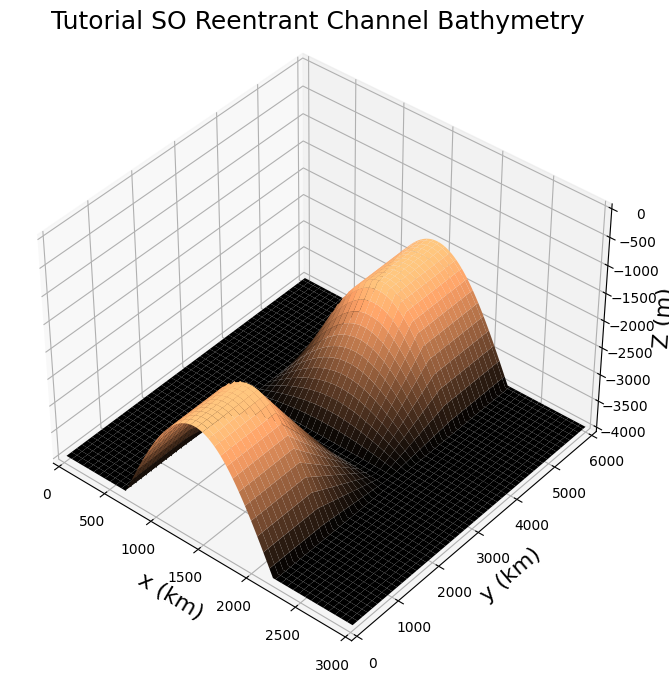

In [17]:
#plot bathymetry as 3D surface plot, as shown in fig 4.10
XC_1km = np.linspace(2500, 5997500, 1200)
YC_1km = np.linspace(2500, 2997500, 600)
YC,XC = np.meshgrid(YC_1km,XC_1km)
plt.figure(figsize=(10,8)) 
ax = plt.axes(projection='3d')
ax.plot_surface(YC[10:,:]/1000,XC[10:,:]/1000, bathy[10:,:], cmap='copper', edgecolor='none');
ax.view_init(40, -50)
ax.set_zlim(-4000,0)
ax.set_zlabel('Z (m)', fontsize=16)
ax.set_title('Tutorial SO Reentrant Channel Bathymetry', fontsize=18)
plt.xlabel('x (km)',fontsize=16); plt.ylabel('y (km)', fontsize=16)
plt.xlim(0,3000)
plt.ylim(0,6000);

In [3]:
import numpy as np
nx = 600
ny = 1200
# zonal wind stress file (linear N→S ramp: 0 at north, 0.8 at south)
taux_max = 0.8
taux = np.zeros((ny, nx), dtype='float32')          # at (XG,YC) points
taux[5:1195,:] = np.linspace(taux_max, 0.0, 1190, dtype='float32').reshape(1190, 1)
taux.astype('>f4').tofile('zonal_wind.5km.bin')

In [1]:
# zonal wind stress file  (matched to coarse-res profile)
import numpy as np
from numpy import sin, pi, exp
nx = 600
ny = 1200
taux_max = 0.2
taux = np.zeros([ny, nx])             # at (XG,YC) points
taux[5:1195,:] = np.reshape(taux_max * sin(np.linspace(0,pi,1190)), [1190,1])
taux.astype('>f4').tofile('zonal_wind.5km.bin')

In [19]:
# 3-D mask for RBCS temperature relaxation
# mask set to zero in surface layer (where core model SST restoring applied)
# note we implement "sponge layer" to match coarse-res dimensions
rbcs_mask = np.zeros([nr, ny, nx])
rbcs_mask[1:,-10:,:] = 1.0
rbcs_mask[1:,-20:-10,:] = 0.25
rbcs_mask.astype('>f4').tofile('T_relax_mask.5km.bin')

# 2-D SST field for relaxation, linear ramp between Tmin and Tmax
Tmax = 10.
Tmin = -2.
sst_relax = np.zeros([ny, nx]) + np.reshape(
            Tmin + (Tmax-Tmin)/40 * np.linspace(0.05,39.95,ny), [ny,1]) # at (XC,YC) points
sst_relax.astype('>f4').tofile('SST_relax.5km.bin')

# 3-D Temperature field for initial conditions and RBCS northern wall profile
h = 500             # e-folding scale for temperature decrease with depth
T_surf = sst_relax; # use 2-D SST relaxation field for surface values
zscale = (exp(-z/h) - exp(H/h)) / ( 1 - exp(H/h))
zscale = np.reshape(zscale, [nr,1,1])
T_3D = np.reshape(T_surf - Tmin, [ 1,ny,nx]) * zscale + Tmin
T_3D.astype('>f4').tofile('temperature.5km.bin')

In [20]:


# 3-D mask for RBCS salinity relaxation
# mask set to zero in surface layer (where core model SSS restoring applied)
# note we implement "sponge layer" to match coarse-res dimensions
rbcs_mask = np.zeros([nr, ny, nx])
rbcs_mask[1:,-10:,:] = 1.0
rbcs_mask[1:,-20:-10,:] = 0.25
rbcs_mask.astype('>f4').tofile('S_relax_mask.5km.bin')

# 2-D SSS field for relaxation, linear ramp between Smin and Smax
Smax = 35.5
Smin = 33.5
sss_relax = np.zeros([ny, nx]) + np.reshape(
            Smin + (Smax-Smin)/40 * np.linspace(0.05,39.95,ny), [ny,1]) # at (XC,YC) points
sss_relax.astype('>f4').tofile('SSS_relax.5km.bin')

# 3-D Salinity field for initial conditions and RBCS northern wall profile
h = 480             # e-folding scale for salinity decrease with depth
S_surf = sss_relax; # use 2-D SSS relaxation field for surface values
zscale = (exp(-z/h) - exp(H/h)) / ( 1 - exp(H/h))
zscale = np.reshape(zscale, [nr,1,1])
S_3D = np.reshape(S_surf - Smin, [ 1,ny,nx]) * zscale + Smin
S_3D.astype('>f4').tofile('salinity.5km.bin')